# 03. 고유값 분해 (Eigenvalue Decomposition)

**목표:** 고유벡터·고유값의 기하학적 의미를 이해하고, PCA와 진동 모드 분석에 연결한다.

**핵심 방정식:**
$$A\vec{v} = \lambda \vec{v}$$

행렬 $A$가 벡터 $\vec{v}$에 작용할 때, **방향은 바뀌지 않고 크기만 $\lambda$배** 변하는 벡터가 고유벡터.

**로보틱스 연결:**
- 관성 텐서의 고유벡터 = 로봇 링크의 주축(principal axis)
- 고유값 분해 → PCA → 포인트 클라우드에서 물체 주축 추출
- 진동 모드 분석 → 로봇 구조의 공진 주파수

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from mpl_toolkits.mplot3d import Axes3D
import os
os.makedirs('assets', exist_ok=True)

plt.rcParams['font.family'] = 'Nanum Gothic'
plt.rcParams['axes.unicode_minus'] = False

## 1. 고유벡터 — 변환 후에도 방향이 유지된다

행렬 A:
[[3. 1.]
 [1. 3.]]

고유값: [4. 2.]
고유벡터 (열벡터):
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]

검증 — A @ v1 = [2.82842712 2.82842712]
λ1 × v1      = [2.82842712 2.82842712]


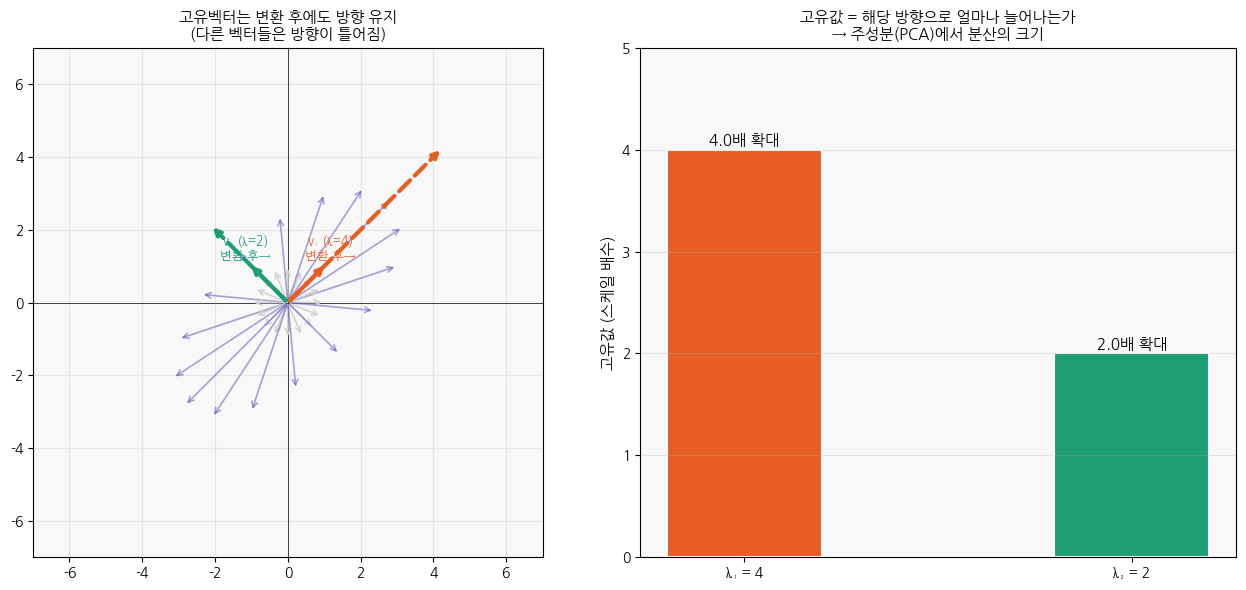

In [8]:
A = np.array([[3., 1.], [1., 3.]])
eigenvalues, eigenvectors = np.linalg.eig(A)

print('행렬 A:')
print(A)
print(f'\n고유값: {eigenvalues}')
print(f'고유벡터 (열벡터):\n{eigenvectors}')
print(f'\n검증 — A @ v1 = {A @ eigenvectors[:,0]}')
print(f'λ1 × v1      = {eigenvalues[0] * eigenvectors[:,0]}')

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# 임의 벡터 여러 개 변환
angles = np.linspace(0, 2*np.pi, 16, endpoint=False)
vecs = np.array([[np.cos(a), np.sin(a)] for a in angles]).T
transformed = A @ vecs

ax = axes[0]
for i in range(vecs.shape[1]):
    ax.annotate('', xy=vecs[:,i], xytext=[0,0],
                arrowprops=dict(arrowstyle='->', color='lightgray', lw=1.2))
    ax.annotate('', xy=transformed[:,i], xytext=[0,0],
                arrowprops=dict(arrowstyle='->', color='#534AB7', lw=1.2, alpha=0.5))

# 고유벡터 강조
for i, (color, label) in enumerate(zip(['#E85D24','#1D9E75'], ['v₁ (λ=4)','v₂ (λ=2)'])):
    v = eigenvectors[:, i]
    lam = eigenvalues[i]
    scale = 1.5
    ax.annotate('', xy=v*scale, xytext=[0,0],
                arrowprops=dict(arrowstyle='->', color=color, lw=3))
    ax.annotate('', xy=v*scale*lam, xytext=[0,0],
                arrowprops=dict(arrowstyle='->', color=color, lw=3, linestyle='dashed'))
    ax.text(*(v*scale*1.1), f'{label}\n변환 후→', color=color, fontsize=9,
            fontweight='bold', ha='center')

ax.set_xlim(-7, 7); ax.set_ylim(-7, 7)
ax.set_aspect('equal'); ax.grid(True, alpha=0.25)
ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
ax.set_title('고유벡터는 변환 후에도 방향 유지\n(다른 벡터들은 방향이 틀어짐)', fontsize=11)

# 고유값 크기 시각화
ax2 = axes[1]
bars = ax2.bar(['λ₁ = 4', 'λ₂ = 2'], eigenvalues,
               color=['#E85D24', '#1D9E75'], width=0.4,
               edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, eigenvalues):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.05,
             f'{val:.1f}배 확대', ha='center', fontsize=11, fontweight='bold')
ax2.set_ylabel('고유값 (스케일 배수)', fontsize=11)
ax2.set_title('고유값 = 해당 방향으로 얼마나 늘어나는가\n→ 주성분(PCA)에서 분산의 크기', fontsize=11)
ax2.set_ylim(0, 5); ax2.grid(True, axis='y', alpha=0.3)
ax2.set_facecolor('#f8f8f8')

plt.tight_layout()
plt.savefig('assets/03_eigendecomposition.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. PCA — 데이터의 주축 찾기

로보틱스 응용: LiDAR 포인트 클라우드에서 물체의 주축(방향)을 PCA로 추출

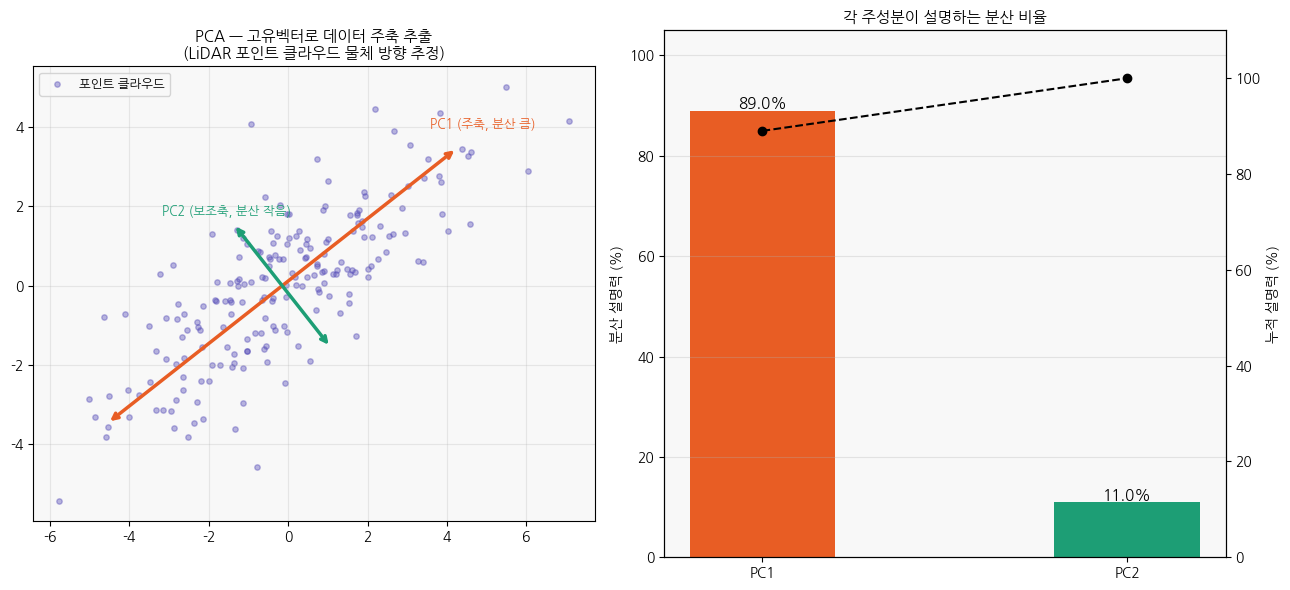

분산 설명력: PC1=89.0%, PC2=11.0%


In [9]:
np.random.seed(42)

# 기울어진 타원형 데이터 (로봇 앞의 물체 포인트 클라우드 가정)
theta = np.pi / 5
R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])
raw = np.random.randn(2, 200) * np.array([[3], [1]])
data = R @ raw

# PCA = 공분산 행렬의 고유벡터
cov = np.cov(data)
eigenvalues, eigenvectors = np.linalg.eig(cov)
idx = np.argsort(eigenvalues)[::-1]  # 내림차순 정렬
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

ax = axes[0]
ax.scatter(data[0], data[1], alpha=0.4, s=15, color='#534AB7', label='포인트 클라우드')

center = data.mean(axis=1)
colors = ['#E85D24', '#1D9E75']
labels = ['PC1 (주축, 분산 큼)', 'PC2 (보조축, 분산 작음)']
for i in range(2):
    scale = np.sqrt(eigenvalues[i]) * 2
    vec = eigenvectors[:, i] * scale
    ax.annotate('', xy=center+vec, xytext=center-vec,
                arrowprops=dict(arrowstyle='<->', color=colors[i], lw=2.5))
    ax.text(*(center + vec * 1.15), labels[i], color=colors[i],
            fontsize=9, fontweight='bold', ha='center')

ax.set_aspect('equal'); ax.grid(True, alpha=0.25)
ax.set_title('PCA — 고유벡터로 데이터 주축 추출\n(LiDAR 포인트 클라우드 물체 방향 추정)', fontsize=11)
ax.legend(fontsize=9)

# 분산 설명력
ax2 = axes[1]
explained = eigenvalues / eigenvalues.sum() * 100
cumulative = np.cumsum(explained)
x = ['PC1', 'PC2']
bars = ax2.bar(x, explained, color=['#E85D24', '#1D9E75'], width=0.4)
ax2_twin = ax2.twinx()
ax2_twin.plot(x, cumulative, 'k--o', lw=1.5, markersize=6, label='누적')
ax2_twin.set_ylabel('누적 설명력 (%)', fontsize=10)
ax2_twin.set_ylim(0, 110)
for bar, val in zip(bars, explained):
    ax2.text(bar.get_x()+bar.get_width()/2, val+0.5,
             f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
ax2.set_ylabel('분산 설명력 (%)', fontsize=10)
ax2.set_title('각 주성분이 설명하는 분산 비율', fontsize=11)
ax2.set_ylim(0, 105); ax2.grid(True, axis='y', alpha=0.3)
ax2.set_facecolor('#f8f8f8')

plt.tight_layout()
plt.savefig('assets/03_pca.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'분산 설명력: PC1={explained[0]:.1f}%, PC2={explained[1]:.1f}%')

## 요약

| 개념 | 의미 | 로보틱스 활용 |
|------|------|---------------|
| 고유벡터 | 변환 후 방향 불변 | 관성 주축, 로봇 링크 방향 |
| 고유값 | 해당 방향 스케일 | 진동 세기, 분산 크기 |
| PCA | 최대 분산 방향 찾기 | 포인트 클라우드 물체 방향 추출 |
| EVD | $A = V\Lambda V^{-1}$ | 관성 텐서 대각화 |

**다음 노트북:** `04_svd.ipynb` — 특이값 분해